In [1]:
using Pkg
Pkg.activate(".")
Pkg.update()

  Activating project at `~/Desktop/julia_codes/RandomLotkaVolterraCavity.jl/simulations`
    Updating registry at `~/.julia/registries/General.toml`
    Updating git-repo `/Users/mattiatarabolo/Desktop/julia_codes/RandomLotkaVolterraCavity.jl`
    Updating `~/Desktop/julia_codes/RandomLotkaVolterraCavity.jl/simulations/Project.toml`
  [e0cb5db2] ~ RandomLotkaVolterraCavity v1.0.0-DEV `/Users/mattiatarabolo/Desktop/julia_codes/RandomLotkaVolterraCavity.jl#main` ⇒ v1.0.0-DEV `/Users/mattiatarabolo/Desktop/julia_codes/RandomLotkaVolterraCavity.jl#main`
    Updating `~/Desktop/julia_codes/RandomLotkaVolterraCavity.jl/simulations/Manifest.toml`
  [e0cb5db2] ~ RandomLotkaVolterraCavity v1.0.0-DEV `/Users/mattiatarabolo/Desktop/julia_codes/RandomLotkaVolterraCavity.jl#main` ⇒ v1.0.0-DEV `/Users/mattiatarabolo/Desktop/julia_codes/RandomLotkaVolterraCavity.jl#main`
Precompiling project...
  ✓ RandomLotkaVolterraCavity
  1 dependency successfully precompiled in 1 seconds. 76 already precompiled.

## Erdos-Ranyi Random graph

In [2]:
using RandomLotkaVolterraCavity
using Random, StatsBase, Distributions
using PyCall, PyPlot
using NLsolve
using SpecialFunctions

# Function to calculate standard error of the mean
sem(x) = std(x) / sqrt(length(x))

# Function to calculate the standard error the median
semean(x) = sem(x)

function normalize!(prob::Vector{Float64})
    l = length(prob)
    norm = 0.0
    for k in 1:l
        norm += prob[k]
    end
    for k in 1:l
        prob[k] = prob[k] / norm
    end
end

function φ_func(x::Float64)
    return exp(-x^2/2)/sqrt(2*pi)
end

function Φ_func(x::Float64)
    return (1+erf(x/sqrt(2)))/2
end

w0_func(Δ) = Φ_func(Δ)
w1_func(Δ) = Δ * Φ_func(Δ) + φ_func(Δ)

w1_func (generic function with 1 method)

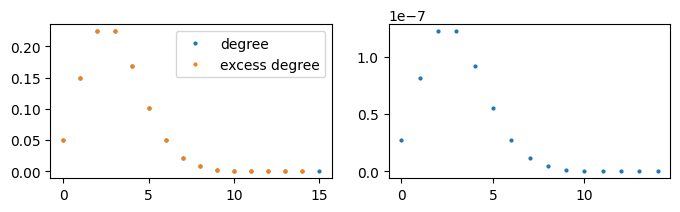

Mean Field stable region
norm degree: 0.9999999999999998, norm excess degree: 1.0


In [3]:
P = Int(1e4)  # Population size
K = 3  # Average degree of the graph
k_max = K*5
degree_pdf = Poisson(K)
p_k = pdf.(degree_pdf, 0:k_max)
normalize!(p_k)
p_cav_k = [(k+1)/K*p_k[k+2] for k in 0:k_max-1] # This is the excess degree distribution, i.e. the cavity degree distribution of an Erdos-Renyi random graph
normalize!(p_cav_k)
tol = 5e-3  # Convergence tolerance
max_iter = Int(1e3)  # Maximum number of iterations
m = 0.0  # Mean coupling
σ² = .5 # Standard deviation of coupling
γ = -1.0  # Correlation coefficient between J and J'

# check to be in the stable region
if (2*m^2/K+(1+γ)*σ²)^2/(m^2/K+σ²)<2*K/(K-1)
    println("Mean Field stable region")
else
    println("Mean field UNSTABLE region!")
end

fig, ax = subplots(1,2,figsize=(8,2))
ax[1].plot(0:k_max, p_k, markersize=4, linestyle="", marker=".", label="degree")
ax[1].plot(0:k_max-1, p_cav_k, markersize=4, linestyle="", marker=".", label="excess degree")
ax[1].legend()
ax[2].plot(0:k_max-1, abs.(p_cav_k.-p_k[1:k_max]), markersize=4, linestyle="", marker=".")
#ax.set_xlim((480,520))
PyPlot.display_figs()
println("norm degree: $(sum(p_k)), norm excess degree: $(sum(p_cav_k))")

In [4]:
rng = Xoshiro(1234)
μ_population, q_population, χ_population, μ_cav_population, q_cav_population, χ_cav_population = population_dynamics(p_k, p_cav_k, P, tol, max_iter, m, σ², γ, K; check_conv=10, rng=rng, verbose=false)

fig, ax = subplots(1, 3, figsize=(15, 5))
ax[1].hist(μ_population, bins=range(0.0, 6.0, length=20), density=true)
ax[1].set_xlabel("μ")
ax[1].set_ylabel("Frequency")
ax[2].hist(q_population, bins=range(0.0, 10.0, length=20), density=true)
ax[2].set_xlabel("q")
ax[3].hist(χ_population, bins=range(0.0, 2.0, length=20), density=true)
ax[3].set_xlabel("χ")
tight_layout()
show()
PyPlot.display_figs()

avg_μ = mean(μ_population)
stde_μ = semean(μ_population)

println("μ = $(avg_μ) ± $(stde_μ)")

Progress:  65%|██████████████████████████▌              |  ETA: 0:00:02

μ=2.6833826373917145e153, q=Inf, χ=556.2314548766494, sum_q=5.637873854215648e301, sum_χ=0.9994419683660365, Δ=-0.49473173768320033


ArgumentError: ArgumentError: Invalid values

## Random-Regular Graph

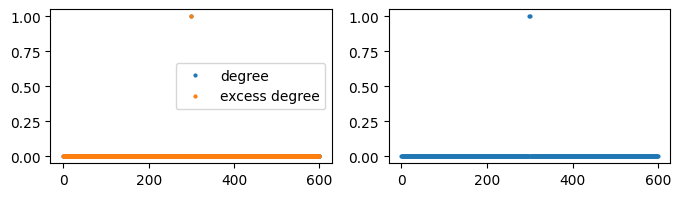

Mean Field stable region
norm degree: 1.0, norm excess degree: 1.0


In [6]:
P = Int(1e4)  # Population size
K = 300  # Average degree of the graph
k_max = K*2
degree_pdf =Poisson(K)
p_k = [Float64(k==K) for k in 0:k_max]
normalize!(p_k)
p_cav_k = [(k+1)/K*p_k[k+2] for k in 0:k_max-1] # This is the excess degree distribution, i.e. the cavity degree distribution of an Erdos-Renyi random graph
normalize!(p_cav_k)
tol = 5e-3  # Convergence tolerance
max_iter = Int(1e4)  # Maximum number of iterations
m = 0.0  # Mean coupling
σ² = 1.0 # Standard deviation of coupling
γ = -1.0  # Correlation coefficient between J and J'

# check to be in the stable region
if (2*m^2/K+(1+γ)*σ²)^2/(m^2/K+σ²)<2*K/(K-1)
    println("Mean Field stable region")
else
    println("Mean field UNSTABLE region!")
end

fig, ax = subplots(1,2,figsize=(8,2))
ax[1].plot(0:k_max, p_k, markersize=4, linestyle="", marker=".", label="degree")
ax[1].plot(0:k_max-1, p_cav_k, markersize=4, linestyle="", marker=".", label="excess degree")
ax[1].legend()
ax[2].plot(0:k_max-1, abs.(p_cav_k.-p_k[1:k_max]), markersize=4, linestyle="", marker=".")
#ax.set_xlim((480,520))
PyPlot.display_figs()
println("norm degree: $(sum(p_k)), norm excess degree: $(sum(p_cav_k))")

In [8]:
rng = Xoshiro(1234)
μ_population, q_population, χ_population, μ_cav_population, q_cav_population, χ_cav_population = population_dynamics(p_k, p_cav_k, P, tol, max_iter, m, σ², γ, K; check_conv=10, rng=rng, verbose=false)
#=
fig, ax = subplots(1, 3, figsize=(15, 5))
ax[1].hist(μ_population, bins=range(0.5, 1.5, length=20), density=true)
ax[1].set_xlabel("μ")
ax[1].set_ylabel("Frequency")
ax[2].hist(q_population, bins=range(0.0, 10.0, length=20), density=true)
ax[2].set_xlabel("q")
ax[3].hist(χ_population, bins=range(0.0, 2.0, length=20), density=true)
ax[3].set_xlabel("χ")
tight_layout()
show()
PyPlot.display_figs()
=#
avg_μ = mean(μ_population)
stde_μ = semean(μ_population)

println("μ = $(avg_μ) ± $(stde_μ)")

Progress: 100%|█████████████████████████████████████████| Time: 0:01:21K


Converged after 20 iterations.
μ = 3.12923909665348077347851673787487622553634861290426926272348202360487468362099 ± 0.02301135119531864601129942151094098759264169964623600930080660619843061149948555


In [6]:
npoints = 100

Δs = 10 .^ (range(log(1.0), log(1000.0), length=npoints))
μs = zeros(npoints)
qs = zeros(npoints)
χs = zeros(npoints)
σs = zeros(npoints)

for (iΔ,Δ) in enumerate(Δs)
    w0 = w0_func(Δ)
    w1 = w1_func(Δ)
    w2 = w0+Δ*w1

    χs[iΔ] = w0+γ*w0^2/w2
    σs[iΔ] = K/(K-1)*w2/(w2+γ*w0)^2
    μs[iΔ] = (Δ/w1*w2/(w2+γ*w0)-(K-1)/K*m)^(-1)
    qs[iΔ] = K/(K-1)*(w2/(w2+γ*w0)*μs[iΔ]/(σs[iΔ]*w1))^2
end

colors = ["red", "orange", "yellow", "green", "blue"]

fig,ax = subplots(1,3,figsize=(10,3))
ax[1].plot(σs, μs)
ax[1].scatter([σ²], [avg_μ], color="red")
ax[1].set_xlabel("σ²")
ax[1].set_ylabel("μ")
ax[2].plot(Δs, σs)
ax[2].set_xscale("log")
ax[2].set_yscale("log")
ax[2].set_xlabel("Δ")
ax[2].set_ylabel("σ²")
ax[3].plot(Δs, μs)
ax[3].set_xlabel("Δ")
ax[3].set_ylabel("μ")
ax[3].set_xscale("log")
#ax[3].set_yscale("log")
PyPlot.display_figs()

MethodError: MethodError: no method matching Φ_func(::Float64)

Closest candidates are:
  Φ_func(!Matched::BigFloat)
   @ Main ~/Desktop/julia_codes/RandomLotkaVolterraCavity.jl/simulations/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W2sZmlsZQ==.jl:28


## Fully Connected case

In [13]:
P = Int(1e4)  # Population size
tol = 1e-3  # Convergence tolerance
max_iter = Int(1e3)  # Maximum number of iterations
m = -1.0  # Mean coupling
σ² = 5.0 # Standard deviation of coupling
γ = -1.0  # Correlation coefficient between J and J'

# check to be in the stable region
if σ²<2/(1+γ)^2
    println("Mean Field stable region")
else
    println("Mean field UNSTABLE region!")
end

Mean Field stable region


In [14]:
rng = Xoshiro(1234)
μ_population, q_population, χ_population = population_dynamics_FC(P, tol, max_iter, m, σ², γ; check_conv=10, rng=rng, verbose=false)

Progress: 100%|█████████████████████████████████████████| Time: 0:02:30


Converged after 70 iterations.


([1.3969926805774637, 0.23604754527563876, 0.3527558987815735, 0.5342045349047918, 0.6308026782249638, 0.11082371333753668, 1.3177775840156363, 1.2350293672923087, 0.09287976118354534, 0.3050710126165474  …  0.24972241466205408, 1.6792422408050398, 0.4714669734125356, 1.1468241717489445, 0.8131927356357966, 0.64914681307766, 1.0380194071571185, 1.1021174765448378, 0.22025578290221853, 0.5267889472284693], [2.6715080222346055, 0.24009519610065194, 0.39453010770948144, 0.6792804588161254, 0.8452348005600427, 0.09671837098253862, 2.446876349363278, 2.2131702298355322, 0.07848064746259259, 0.32889858486248164  …  0.2584508967524371, 3.580420855275274, 0.5754235570237278, 1.9919042571222765, 1.2027586751616604, 0.8804488817954512, 1.7104614159753089, 1.8680398341389723, 0.21895217442106454, 0.6673972463841656], [0.41652341245013463, 0.16755950875949258, 0.22345851811043727, 0.27830807035007904, 0.304564307622577, 0.09524932634781151, 0.41411736224922385, 0.40608202872347965, 0.0842979795175

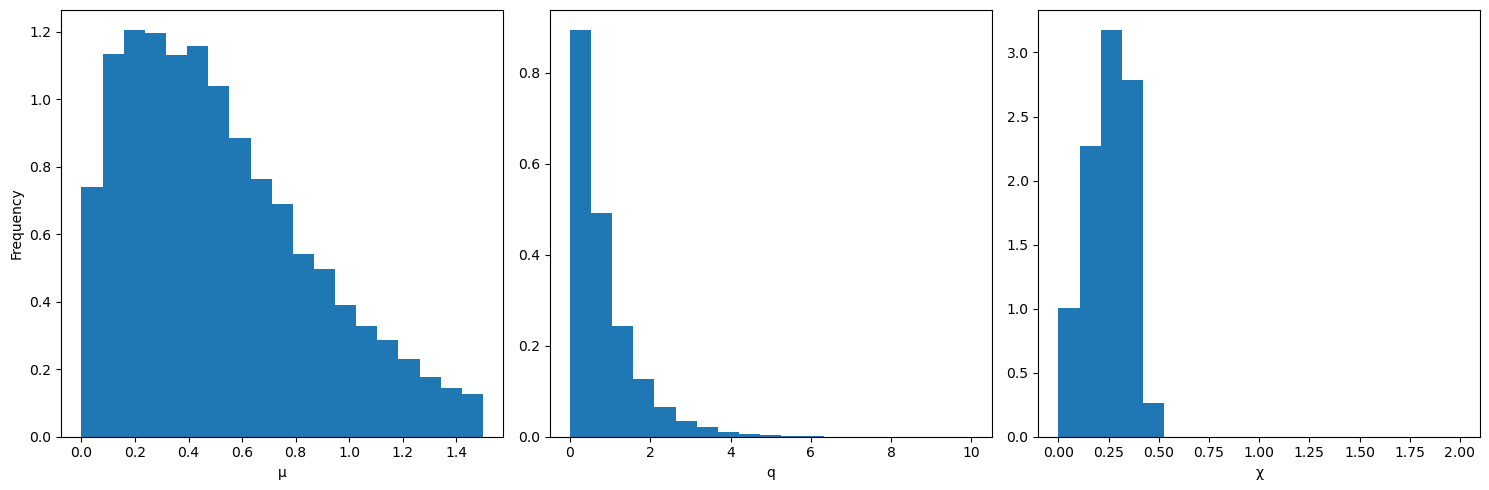

μ = 0.46998561842397624 ± 0.003963279598741191


In [15]:
fig, ax = subplots(1, 3, figsize=(15, 5))
ax[1].hist(μ_population, bins=range(0.0, 1.5, length=20), density=true)
ax[1].set_xlabel("μ")
ax[1].set_ylabel("Frequency")
ax[2].hist(q_population, bins=range(0.0, 10.0, length=20), density=true)
ax[2].set_xlabel("q")
ax[3].hist(χ_population, bins=range(0.0, 2.0, length=20), density=true)
ax[3].set_xlabel("χ")
tight_layout()
show()
PyPlot.display_figs()

avg_μ = median(μ_population)
stde_μ = semean(μ_population)

println("μ = $(avg_μ) ± $(stde_μ)")